<a href="https://colab.research.google.com/github/ehsankarami1358/BE_HYDRO/blob/main/H%C4%B0LLCHART_VS_ACTUAL_BEY_U1_2026_r1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import LinearNDInterpolator
import os


In [23]:
# ---------------------------
# INPUT FILES (your uploads)
# ---------------------------
hill_path = r"/content/BEY_Digital_hillchart_extracted.xlsx"
op_path   = r"/content/u1_1_3_2026_12_3_2026_r1.csv"
out_dir   = r"/content/data"

# Create the output directory if it doesn't exist
os.makedirs(out_dir, exist_ok=True)

In [24]:
# ---------------------------
# 1) LOAD + PARSE HILL CHART
# ---------------------------
hill_raw = pd.read_excel(hill_path, sheet_name="Sheet1")

def parse_hill_blocks(df):
    blocks = []
    i = 0
    while i < len(df):
        v = df.iloc[i, 0]
        if isinstance(v, str) and v.strip().startswith("NetHead_m="):
            head = float(v.split("=")[1])

            # find next row with "ActivePower_MW"
            j = i + 1
            while j < min(i + 8, len(df)) and not (
                isinstance(df.iloc[j, 0], str) and df.iloc[j, 0].strip() == "ActivePower_MW"
            ):
                j += 1
            if j >= len(df):
                i += 1
                continue

            power = pd.to_numeric(df.iloc[j,   1:], errors="coerce").values
            flow  = pd.to_numeric(df.iloc[j+1, 1:], errors="coerce").values
            eta   = pd.to_numeric(df.iloc[j+2, 1:], errors="coerce").values
            opn   = pd.to_numeric(df.iloc[j+3, 1:], errors="coerce").values

            block = pd.DataFrame({
                "Head_m": head,
                "Power_MW": power,
                "Flow_m3s": flow,
                "Eta_hill": eta,
                "Opening_hill_pct": opn
            }).dropna(subset=["Power_MW", "Flow_m3s", "Eta_hill"])

            blocks.append(block)
            i = j + 4
        else:
            i += 1

    if blocks:
        return pd.concat(blocks, ignore_index=True)
    return pd.DataFrame(columns=["Head_m","Power_MW","Flow_m3s","Eta_hill","Opening_hill_pct"])

hill_table = parse_hill_blocks(hill_raw)

In [25]:
hill_table

,Head_m,Power_MW,Flow_m3s,Eta_hill,Opening_hill_pct
0,70.0,140.0,222.0,0.920,NaN
1,70.0,150.0,235.0,0.935,NaN
2,70.0,155.0,241.0,0.945,NaN
3,70.0,160.0,247.0,0.950,NaN
4,70.0,165.0,252.0,0.956,NaN
5,70.0,170.0,259.0,0.960,NaN
6,70.0,175.0,267.0,0.960,NaN
7,70.0,180.0,275.0,0.956,NaN
8,72.5,140.0,217.0,0.921,NaN
9,72.5,150.0,227.0,0.930,NaN


In [26]:
# Interpolators: Flow(H,P) and Eta(H,P)
X = hill_table[["Head_m","Power_MW"]].values
flow_interp = LinearNDInterpolator(X, hill_table["Flow_m3s"].values)
eta_interp  = LinearNDInterpolator(X, hill_table["Eta_hill"].values)
display(flow_interp)

In [27]:
# ---------------------------
# 2) LOAD OPERATING CSV
# ---------------------------
op = pd.read_csv(op_path)
op["Timestamp"] = pd.to_datetime(op["Timestamp"], errors="coerce")

op["NetHead_m"] = op["HEAD_L(m)"] - op["TAIL_L(m)"]
op["Power_MW"]  = op["ACTIVE_POWER(MW)"]
op["Flow_m3s"]  = op["FLOW(m3/s)"]
op["Opening_pct"] = op["OPPENING(%)"]
op["Speed_rpm"] = op["SPEED(RPM)"]

op = op.dropna(subset=["Timestamp","NetHead_m","Power_MW","Flow_m3s","Speed_rpm"])

# Nominal speed from running points
run_mask = (op["Power_MW"] > 20) & (op["Flow_m3s"] > 5)
nom_speed = op.loc[run_mask, "Speed_rpm"].median()

# Stable filter (tune if needed)
stable_mask = (
    (op["Power_MW"] > 20) &
    (op["Flow_m3s"] > 5) &
    (op["Opening_pct"] > 1) &
    (op["Speed_rpm"].between(nom_speed - 0.5, nom_speed + 0.5))
)
op_stable = op.loc[stable_mask].copy()

In [28]:

# ---------------------------
# 3) ACTUAL EFFICIENCY
# ---------------------------
rho = 1000.0
g = 9.80665
electrical_efficiency = 0.98 # As per user request
op_stable["Eta_actual"] = (op_stable["Power_MW"]*1e6) / (rho*g*op_stable["Flow_m3s"]*op_stable["NetHead_m"])
op_stable["Eta_actual"] = op_stable["Eta_actual"] / electrical_efficiency # Convert overall to mechanical efficiency

# ---------------------------
# 4) EXPECTED FROM HILL CHART
# ---------------------------
op_stable["Flow_expected"] = flow_interp(op_stable["NetHead_m"].values, op_stable["Power_MW"].values)
op_stable["Eta_expected"]  = eta_interp(op_stable["NetHead_m"].values, op_stable["Power_MW"].values)

# Keep only points inside hill chart domain
op_cmp = op_stable.dropna(subset=["Flow_expected","Eta_expected"]).copy()

op_cmp["Flow_error_m3s"] = op_cmp["Flow_m3s"] - op_cmp["Flow_expected"]
op_cmp["Flow_error_pct"] = 100.0 * op_cmp["Flow_error_m3s"] / op_cmp["Flow_expected"]

op_cmp["Eta_error"]      = op_cmp["Eta_actual"] - op_cmp["Eta_expected"]
op_cmp["Eta_error_pct"]  = 100.0 * op_cmp["Eta_error"] / op_cmp["Eta_expected"]

# ---------------------------
# 5) QUICK SUMMARY
# ---------------------------
print("Stable points:", len(op_cmp))
print("Net head range (m):", op_cmp["NetHead_m"].min(), "to", op_cmp["NetHead_m"].max())
print("Power range (MW):", op_cmp["Power_MW"].min(), "to", op_cmp["Power_MW"].max())
print("Net head mean (m):",op_cmp["NetHead_m"].mean())
print("Power range (MW):",op_cmp["Power_MW"].mean())

Stable points: 283
Net head range (m): 71.6155 to 76.42450000000008
Power range (MW): 146.7774 to 179.5573
Net head mean (m): 73.53194169611307
Power range (MW): 159.676845229682


In [29]:
print(op_stable[["NetHead_m","Power_MW","Flow_expected","Eta_expected"]])

      NetHead_m  Power_MW  Flow_expected  Eta_expected
66      76.8182  164.5845            NaN           NaN
67      76.7894  164.8231            NaN           NaN
68      75.8881  165.7486     237.788267      0.939379
69      75.0480  159.4798     232.423840      0.934456
70      74.8227  151.6047     223.243060      0.927209
...         ...       ...            ...           ...
1006    73.0313  157.1592     234.884080      0.936316
1007    72.8007  161.1431     239.650040      0.941193
1008    72.7231  165.2308     244.784600      0.945092
1009    72.7814  161.3629     239.960120      0.941415
1010    72.8501  158.7121     236.871860      0.938614

[288 rows x 4 columns]


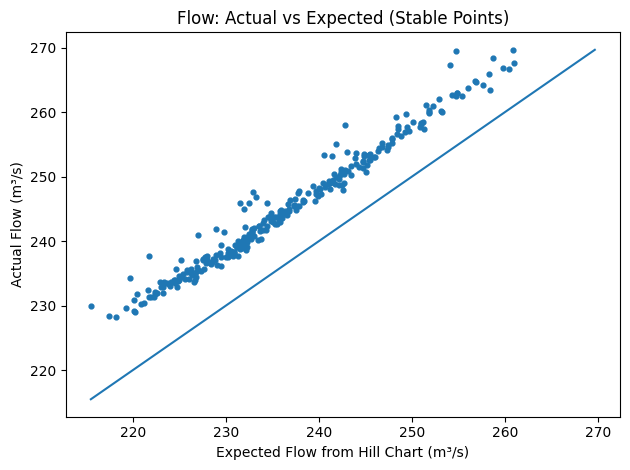

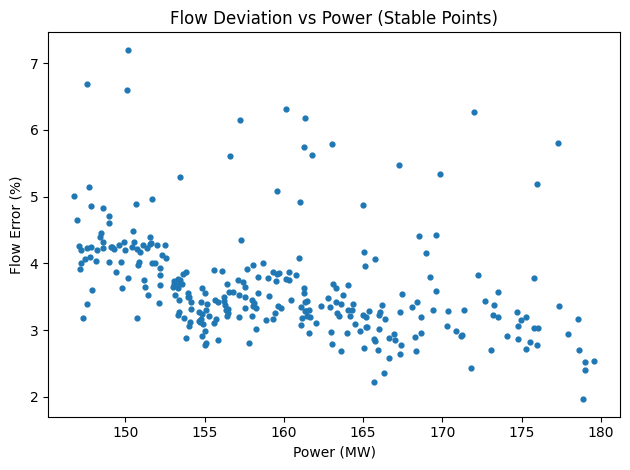

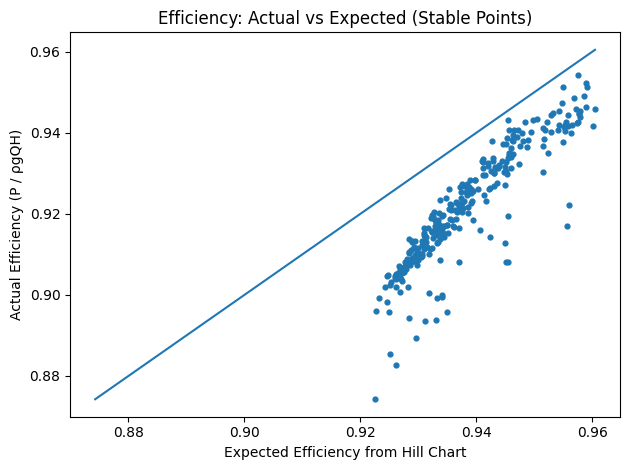

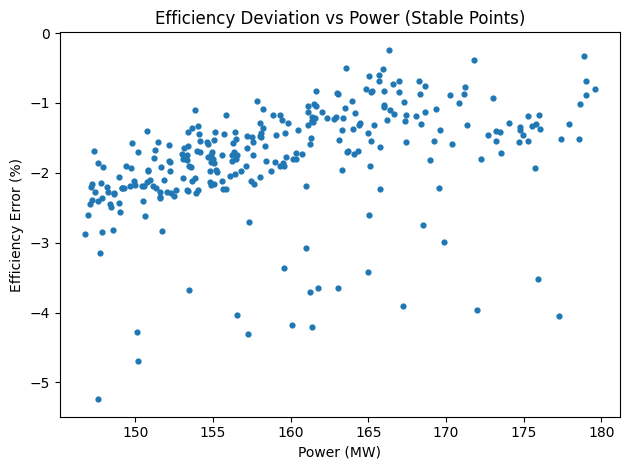

In [30]:
# ---------------------------
# 6) PLOTS (no seaborn)
# ---------------------------
# Actual vs Expected Flow
plt.figure()
plt.scatter(op_cmp["Flow_expected"], op_cmp["Flow_m3s"], s=12)
mn = min(op_cmp["Flow_expected"].min(), op_cmp["Flow_m3s"].min())
mx = max(op_cmp["Flow_expected"].max(), op_cmp["Flow_m3s"].max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel("Expected Flow from Hill Chart (m³/s)")
plt.ylabel("Actual Flow (m³/s)")
plt.title("Flow: Actual vs Expected (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "flow_actual_vs_expected.png"), dpi=200)
plt.show()

# Flow error vs Power
plt.figure()
plt.scatter(op_cmp["Power_MW"], op_cmp["Flow_error_pct"], s=12)
plt.xlabel("Power (MW)")
plt.ylabel("Flow Error (%)")
plt.title("Flow Deviation vs Power (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "flow_error_pct_vs_power.png"), dpi=200)
plt.show()

# Efficiency actual vs expected
plt.figure()
plt.scatter(op_cmp["Eta_expected"], op_cmp["Eta_actual"], s=12)
mn = min(op_cmp["Eta_expected"].min(), op_cmp["Eta_actual"].min())
mx = max(op_cmp["Eta_expected"].max(), op_cmp["Eta_actual"].max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel("Expected Efficiency from Hill Chart")
plt.ylabel("Actual Efficiency (P / ρgQH)")
plt.title("Efficiency: Actual vs Expected (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "eta_actual_vs_expected.png"), dpi=200)
plt.show()

# Efficiency error vs Power
plt.figure()
plt.scatter(op_cmp["Power_MW"], op_cmp["Eta_error_pct"], s=12)
plt.xlabel("Power (MW)")
plt.ylabel("Efficiency Error (%)")
plt.title("Efficiency Deviation vs Power (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "eta_error_pct_vs_power.png"), dpi=200)
plt.show()

# ---------------------------

In [31]:
# 7) EXPORT REPORT TO EXCEL
# ---------------------------
summary = pd.DataFrame([
    {
        "n_stable_points": len(op_cmp),
        "net_head_min_m": float(op_cmp["NetHead_m"].min()),
        "net_head_max_m": float(op_cmp["NetHead_m"].max()),
        "power_min_MW": float(op_cmp["Power_MW"].min()),
        "power_max_MW": float(op_cmp["Power_MW"].max()),
        "flow_error_mean_pct": float(op_cmp["Flow_error_pct"].mean()),
        "flow_error_median_pct": float(op_cmp["Flow_error_pct"].median()),
        "eta_error_mean_pct": float(op_cmp["Eta_error_pct"].mean()),
        "eta_error_median_pct": float(op_cmp["Eta_error_pct"].median()),
    }
])

report_path = os.path.join(out_dir, "unit2_vs_hillchart_report.xlsx")
with pd.ExcelWriter(report_path, engine="openpyxl") as w:
    summary.to_excel(w, index=False, sheet_name="Summary")
    hill_table.to_excel(w, index=False, sheet_name="Hill_flat_table")
    op_cmp.to_excel(w, index=False, sheet_name="Stable_points_with_compare")

print("Saved:", report_path)

Saved: /content/data/unit2_vs_hillchart_report.xlsx


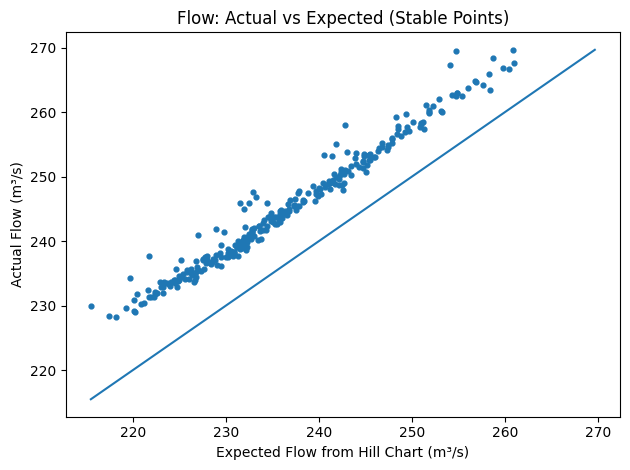

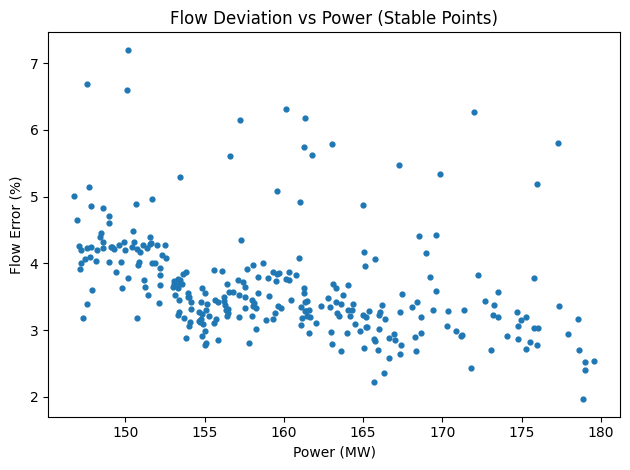

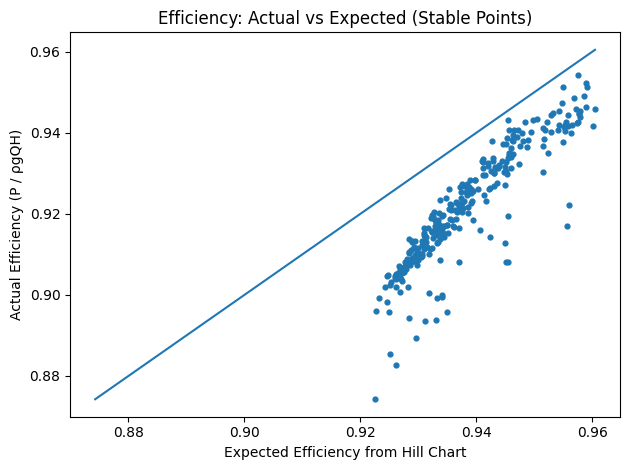

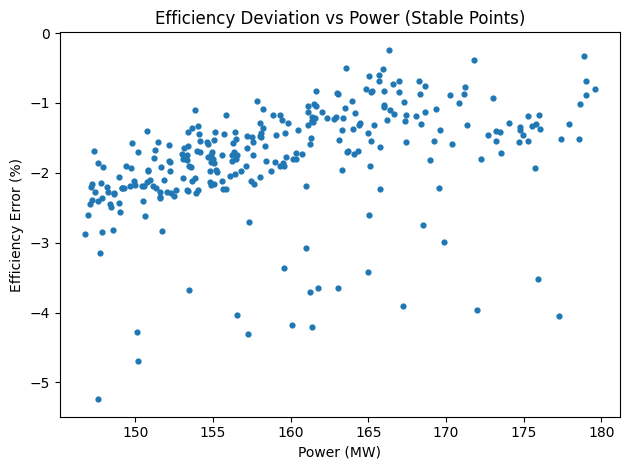

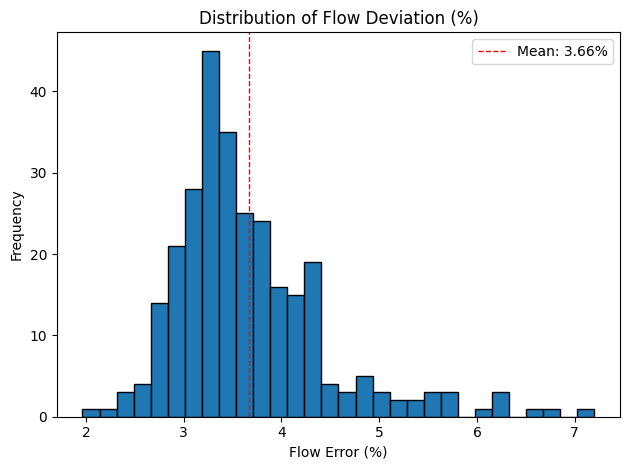

Mean Flow Error: 3.66%


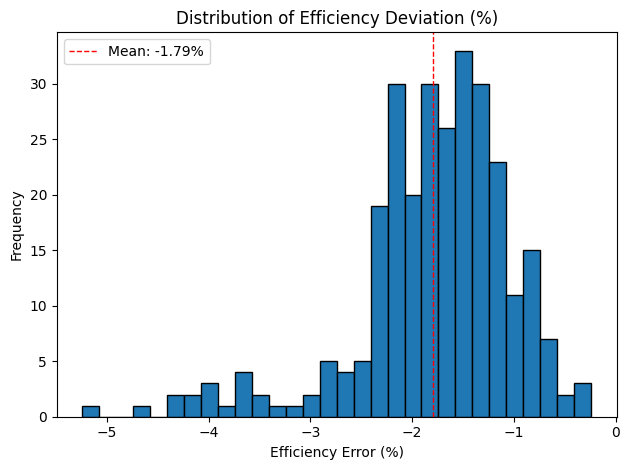

Mean Efficiency Error: -1.79%


In [32]:
# ---------------------------
# 6) PLOTS (no seaborn)
# ---------------------------
# Actual vs Expected Flow
plt.figure()
plt.scatter(op_cmp["Flow_expected"], op_cmp["Flow_m3s"], s=12)
mn = min(op_cmp["Flow_expected"].min(), op_cmp["Flow_m3s"].min())
mx = max(op_cmp["Flow_expected"].max(), op_cmp["Flow_m3s"].max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel("Expected Flow from Hill Chart (m³/s)")
plt.ylabel("Actual Flow (m³/s)")
plt.title("Flow: Actual vs Expected (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "flow_actual_vs_expected.png"), dpi=200)
plt.show()

# Flow error vs Power
plt.figure()
plt.scatter(op_cmp["Power_MW"], op_cmp["Flow_error_pct"], s=12)
plt.xlabel("Power (MW)")
plt.ylabel("Flow Error (%)")
plt.title("Flow Deviation vs Power (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "flow_error_pct_vs_power.png"), dpi=200)
plt.show()

# Efficiency actual vs expected
plt.figure()
plt.scatter(op_cmp["Eta_expected"], op_cmp["Eta_actual"], s=12)
mn = min(op_cmp["Eta_expected"].min(), op_cmp["Eta_actual"].min())
mx = max(op_cmp["Eta_expected"].max(), op_cmp["Eta_actual"].max())
plt.plot([mn,mx],[mn,mx])
plt.xlabel("Expected Efficiency from Hill Chart")
plt.ylabel("Actual Efficiency (P / ρgQH)")
plt.title("Efficiency: Actual vs Expected (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "eta_actual_vs_expected.png"), dpi=200)
plt.show()

# Efficiency error vs Power
plt.figure()
plt.scatter(op_cmp["Power_MW"], op_cmp["Eta_error_pct"], s=12)
plt.xlabel("Power (MW)")
plt.ylabel("Efficiency Error (%)")
plt.title("Efficiency Deviation vs Power (Stable Points)")
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "eta_error_pct_vs_power.png"), dpi=200)
plt.show()

# Histogram for Flow Error Percentage
plt.figure()
plt.hist(op_cmp["Flow_error_pct"], bins=30, edgecolor='black')
flow_error_mean = op_cmp["Flow_error_pct"].mean()
plt.axvline(flow_error_mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {flow_error_mean:.2f}%')
plt.xlabel("Flow Error (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Flow Deviation (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "flow_error_pct_histogram.png"), dpi=200)
plt.show()
print(f"Mean Flow Error: {flow_error_mean:.2f}%")

# Histogram for Efficiency Error Percentage
plt.figure()
plt.hist(op_cmp["Eta_error_pct"], bins=30, edgecolor='black')
eta_error_mean = op_cmp["Eta_error_pct"].mean()
plt.axvline(eta_error_mean, color='red', linestyle='dashed', linewidth=1, label=f'Mean: {eta_error_mean:.2f}%')
plt.xlabel("Efficiency Error (%)")
plt.ylabel("Frequency")
plt.title("Distribution of Efficiency Deviation (%)")
plt.legend()
plt.tight_layout()
plt.savefig(os.path.join(out_dir, "eta_error_pct_histogram.png"), dpi=200)
plt.show()
print(f"Mean Efficiency Error: {eta_error_mean:.2f}%")

# ---------------------------

In [38]:
# Extract the year from the 'Timestamp' column
op_cmp['Year'] = op_cmp['Timestamp'].dt.year

# Define head bins
head_bins = [73, 74, 75, 76, np.inf] # Including np.inf to catch values above 85
head_labels = ['73-74m', '74-75m', '75-76m', '>76m']
op_cmp['Head_bin'] = pd.cut(op_cmp['NetHead_m'], bins=head_bins, labels=head_labels, right=False)

# Define power bins (5 MW intervals)
min_power = int(op_cmp['Power_MW'].min() // 5) * 5
max_power = int(op_cmp['Power_MW'].max() // 5 + 1) * 5
power_bins = np.arange(min_power, max_power + 5, 5)
power_labels = [f'{i}-{i+5}MW' for i in power_bins[:-1]]
op_cmp['Power_bin'] = pd.cut(op_cmp['Power_MW'], bins=power_bins, labels=power_labels, right=False)

# Display the first few rows with the new columns
print(op_cmp[['Timestamp', 'Year', 'NetHead_m', 'Head_bin', 'Power_MW', 'Power_bin', 'Eta_actual']].head())

             Timestamp  Year  NetHead_m Head_bin  Power_MW  Power_bin  \
68 2026-03-02 03:54:00  2026    75.8881   75-76m  165.7486  165-170MW   
69 2026-03-02 04:09:00  2026    75.0480   75-76m  159.4798  155-160MW   
70 2026-03-02 04:24:00  2026    74.8227   74-75m  151.6047  150-155MW   
71 2026-03-02 04:39:00  2026    74.8369   74-75m  167.3311  165-170MW   
72 2026-03-02 04:54:00  2026    74.8718   74-75m  174.7749  170-175MW   

    Eta_actual  
68    0.918419  
69    0.917100  
70    0.905414  
71    0.934073  
72    0.940776  


In [39]:
op_cmp['Year'] = op_cmp['Timestamp'].dt.year

head_bins = [73, 74, 75, 76, np.inf]
head_labels = ['73-74m', '74-75m', '75-76m', '>76m']
op_cmp['Head_bin'] = pd.cut(op_cmp['NetHead_m'], bins=head_bins, labels=head_labels, right=False)

min_power = op_cmp['Power_MW'].min()
max_power = op_cmp['Power_MW'].max()
power_bins = np.arange(np.floor(min_power / 5) * 5, np.ceil(max_power / 5) * 5 + 5, 5)
power_labels = [f'{int(i)}-{int(i+5)}MW' for i in power_bins[:-1]]
op_cmp['Power_bin'] = pd.cut(op_cmp['Power_MW'], bins=power_bins, labels=power_labels, right=False)

print("DataFrame with new 'Year', 'Head_bin', and 'Power_bin' columns:")
display(op_cmp[['Timestamp', 'Year', 'NetHead_m', 'Head_bin', 'Power_MW', 'Power_bin', 'Eta_actual']].head())

DataFrame with new 'Year', 'Head_bin', and 'Power_bin' columns:


,Timestamp,Year,NetHead_m,Head_bin,Power_MW,Power_bin,Eta_actual
68,2026-03-02 03:54:00,2026,75.8881,75-76m,165.7486,165-170MW,0.918419
69,2026-03-02 04:09:00,2026,75.0480,75-76m,159.4798,155-160MW,0.917100
70,2026-03-02 04:24:00,2026,74.8227,74-75m,151.6047,150-155MW,0.905414
71,2026-03-02 04:39:00,2026,74.8369,74-75m,167.3311,165-170MW,0.934073
72,2026-03-02 04:54:00,2026,74.8718,74-75m,174.7749,170-175MW,0.940776


In [40]:
median_eta_per_bin = op_cmp.groupby(['Year', 'Head_bin', 'Power_bin'])['Eta_actual'].median().reset_index()

print("Median Efficiency per Year, Head Bin, and Power Bin:")
display(median_eta_per_bin.head())


Median Efficiency per Year, Head Bin, and Power Bin:


/tmp/ipykernel_299/3743553023.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  median_eta_per_bin = op_cmp.groupby(['Year', 'Head_bin', 'Power_bin'])['Eta_actual'].median().reset_index()


,Year,Head_bin,Power_bin,Eta_actual
0,2026,73-74m,145-150MW,0.904717
1,2026,73-74m,150-155MW,0.914666
2,2026,73-74m,155-160MW,0.920846
3,2026,73-74m,160-165MW,0.929084
4,2026,73-74m,165-170MW,0.935799


In [41]:
median_eta_per_bin = op_cmp.groupby(['Year', 'Head_bin', 'Power_bin'], observed=False)['Eta_actual'].median().reset_index()

print("Median Efficiency per Year, Head Bin, and Power Bin:")
display(median_eta_per_bin.head())

Median Efficiency per Year, Head Bin, and Power Bin:


,Year,Head_bin,Power_bin,Eta_actual
0,2026,73-74m,145-150MW,0.904717
1,2026,73-74m,150-155MW,0.914666
2,2026,73-74m,155-160MW,0.920846
3,2026,73-74m,160-165MW,0.929084
4,2026,73-74m,165-170MW,0.935799


Visualizing Median Efficiency per Head Bin:


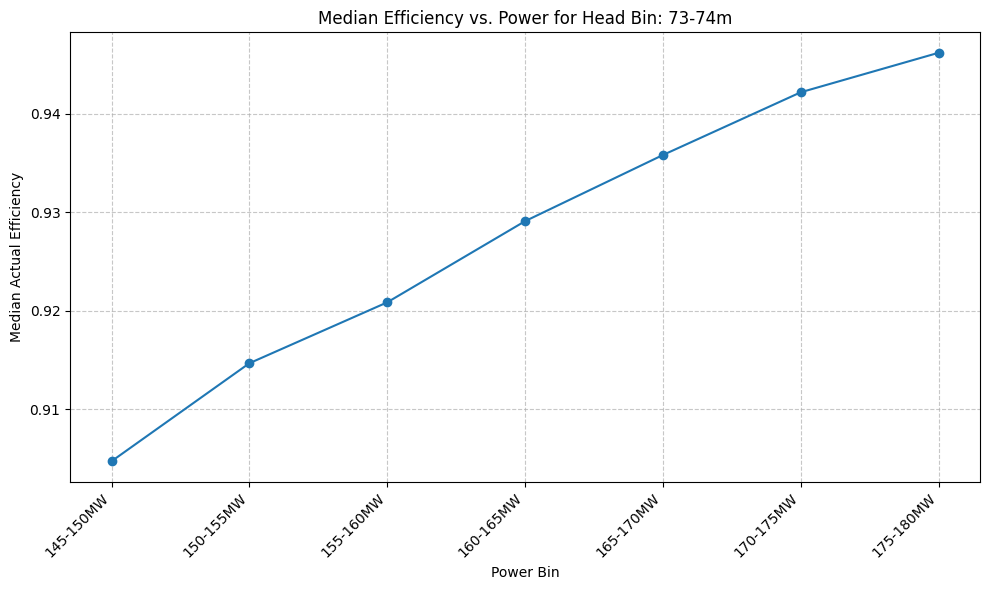

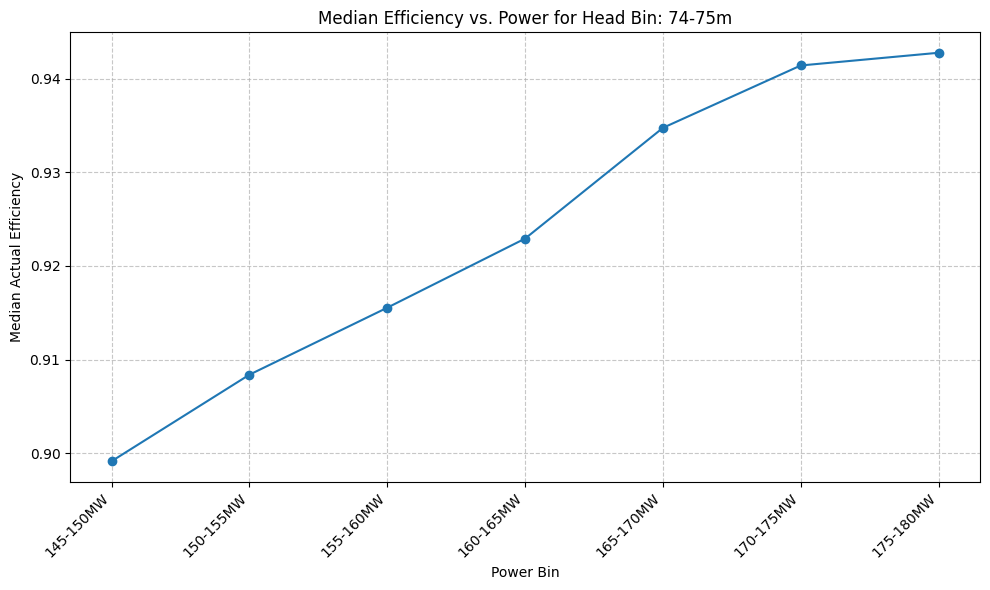

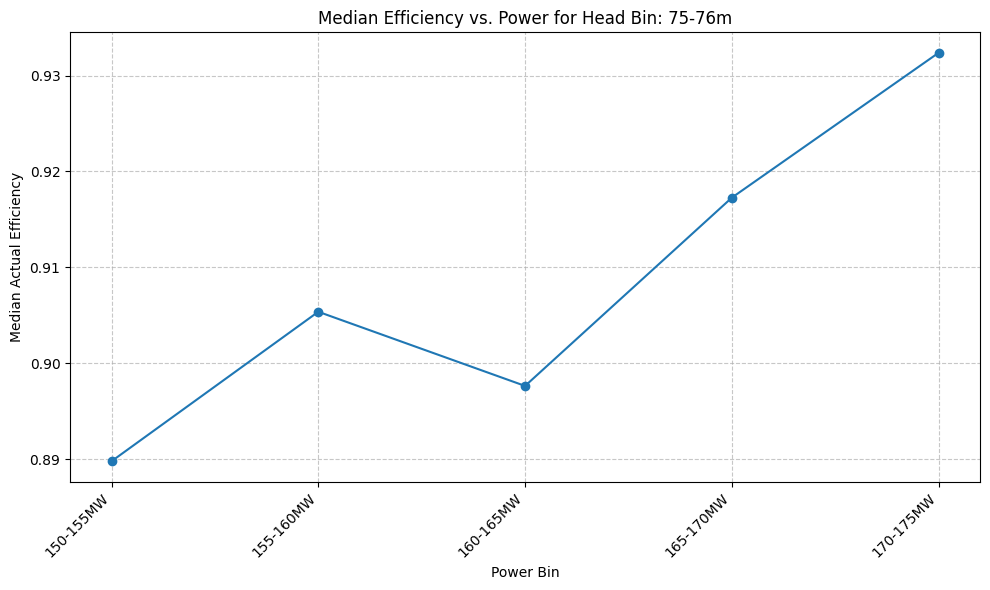

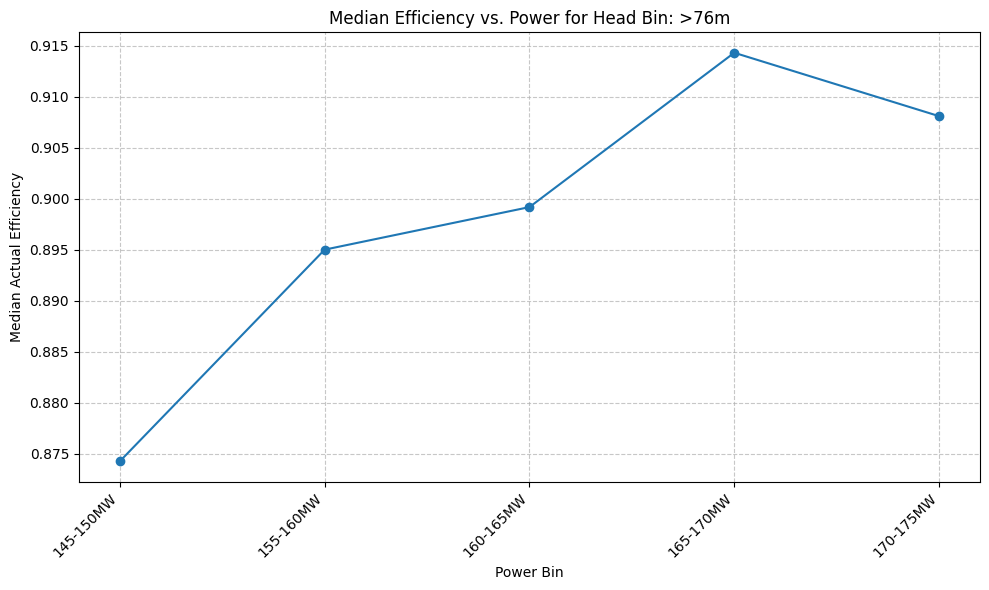

In [42]:
print("Visualizing Median Efficiency per Head Bin:")

# Iterate through each unique 'Head_bin' and create a plot
for head_bin_val in median_eta_per_bin['Head_bin'].unique():
    plt.figure(figsize=(10, 6))
    filtered_data = median_eta_per_bin[median_eta_per_bin['Head_bin'] == head_bin_val].dropna(subset=['Eta_actual'])

    if not filtered_data.empty:
        # Ensure 'Power_bin' is ordered correctly for plotting
        filtered_data['Power_bin_order'] = filtered_data['Power_bin'].apply(lambda x: int(x.split('-')[0]))
        filtered_data = filtered_data.sort_values(by='Power_bin_order')

        plt.plot(filtered_data['Power_bin'], filtered_data['Eta_actual'], marker='o')
        plt.xlabel("Power Bin")
        plt.ylabel("Median Actual Efficiency")
        plt.title(f"Median Efficiency vs. Power for Head Bin: {head_bin_val}")
        plt.xticks(rotation=45, ha='right')
        plt.grid(True, linestyle='--', alpha=0.7)
        plt.tight_layout()